# **CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING**

# **INTRODUCTION**

Customer segmentation is the process of dividing customers into groups based on their behaviour and characteristics . This project uses K-Means Clustering to identify different types of customers based on features like age , income and spending habits . Businesses can use this improve marketing strategies and customer targeting.

# **OBJECTIVES**

*   To segment customers into groups .
*   To identify customer behaviour patterns .

*   To help businesses target customers effectively .

# **TOOLS & TECHNOLOGIES USED**

*   Python
*   Pandas

*   NumPy
*   Matplotlib / Seaborn

*   Scikit-learn

# **ENVIRONMENT SETUP**

In [31]:
pip install pandas numpy matplotlib seaborn scikit-learn plotly

# **IMPORT & UPLOAD FILE**

In [2]:
from google.colab import files
uploaded =  files.upload()

Saving customer_segmentation.csv to customer_segmentation.csv


# **IMPORT LIBRARIES**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **LOAD DATASET**

In [4]:
df = pd.read_csv("customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# **UNDERSTAND DATA**

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# **CHECKING COLUMNS**

In [8]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalSpending'],
      dtype='object')


# **FEATURE SELECTION**

In [13]:
df_selected = df[['Age','Income','TotalSpending']]
df_selected.head()

,Age,Income,TotalSpending
0,57,58138.0,1617
1,60,46344.0,27
2,49,71613.0,776
3,30,26646.0,53
4,33,58293.0,422


# **DATA CLEANING STEP**

In [15]:
print("Before:" , df.shape)
df= df.dropna()
print("After:" , df.shape)

Before: (2216, 31)
After: (2216, 31)


# **DATA SCALING**

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_selected = df_selected.dropna() # Ensure df_selected is free of NaNs
df_scaled = scaler.fit_transform(df_selected)
print(df_scaled[:5])

[[ 0.98644293  0.2340627   1.67548812]
 [ 1.23680074 -0.23455948 -0.96235832]
 [ 0.31882209  0.76947764  0.28024985]
 [-1.2667774  -1.01723878 -0.91922372]
 [-1.01641959  0.24022146 -0.30704427]]


# **ELBOW METHOD**

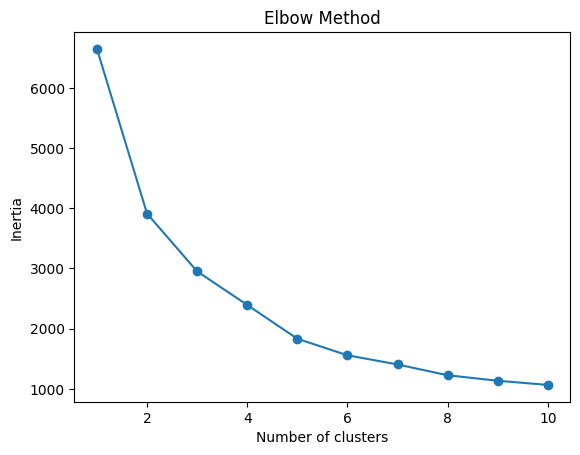

In [29]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(df_scaled)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,11),inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# **K-MEANS CLUSTERING**

In [26]:
kmeans = KMeans(n_clusters=5,random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,57,1617,4
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,60,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,49,776,4
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,30,53,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,33,422,0


# **DATA VISUALIZATION**

# **2D PLOT VISUALIZATION**

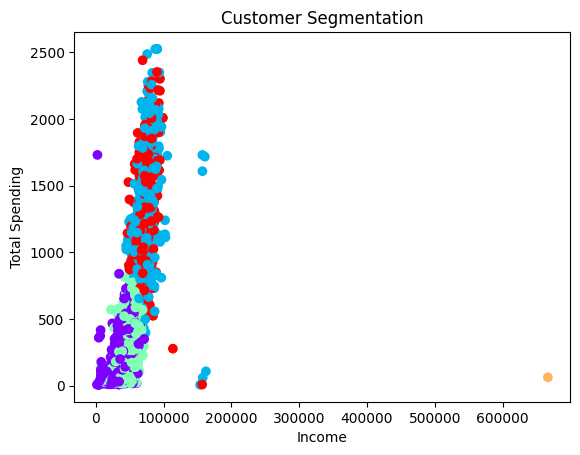

In [27]:
plt.scatter(df['Income'],df['TotalSpending'],c=df['Cluster'],cmap='rainbow')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.title("Customer Segmentation")
plt.show()

# **3D PLOT VISUALIZATION**

In [33]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


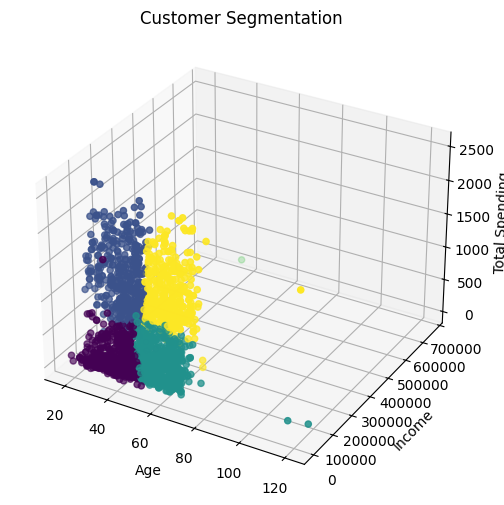

In [35]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['Age'],df['Income'],df['TotalSpending'],c=df['Cluster'])
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Total Spending')
ax.set_title('Customer Segmentation')
plt.show()

# **INTERACTIVE PLOT**

In [36]:
import plotly.express as px
fig = px.scatter_3d(df,x='Age',y='Income',z='TotalSpending',color='Cluster',symbol='Cluster', title ='3D Customer Segmentation')
fig.show()

# **ANALYZE CLUSTERS**

In [30]:
df.groupby('Cluster').mean(numeric_only=True)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5570.913520,1977.404385,34228.068210,0.811206,0.327649,48.064555,63.939099,7.373934,36.423873,10.886724,...,0.010962,0.000000,0.003654,0.000000,0.009744,3.0,11.0,0.113276,36.595615,148.496955
1,5486.571744,1977.046358,73664.443709,0.134658,0.381898,49.441501,621.273731,58.704194,383.571744,81.536424,...,0.152318,0.211921,0.165563,0.035320,0.004415,3.0,11.0,0.245033,36.953642,1280.399558
2,5646.707407,1958.190741,45456.940741,0.437037,0.901852,49.811111,153.092593,9.600000,50.092593,13.575926,...,0.062963,0.000000,0.007407,0.007407,0.016667,3.0,11.0,0.079630,55.809259,264.635185
3,9432.000000,1977.000000,666666.000000,1.000000,0.000000,23.000000,9.000000,14.000000,18.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,37.000000,62.000000
4,5650.872818,1956.246883,72556.753117,0.037406,0.476309,49.458853,647.064838,51.271820,347.463840,75.291771,...,0.129676,0.164589,0.149626,0.024938,0.004988,3.0,11.0,0.214464,57.753117,1247.822943


# **CUSTOMER SEGMENTATION INSIGHTS**

**Cluster 0 - Low Value Customers**

*   Income : Medium (~34k)
*   Spending : Low ( very low product purchases )
*   Recency : High ( not active recently )

**Insight :** These customers spend very little and are not highly engaged . They are low - value customers .

**Business Strategy :**
*   Offer discounts & Promotions .
*   Use email marketing to re-engage .

**Cluster 1 - High Value Customers (VIP)**
* Income : High ( ~73k)
*   Spending : Very High ( high across all products)
*   Recency : Moderate

**Insight :** These are your **best customers** - high income and high spending .

**Business Strategy :**
*   Provide premium offers .
*   Loyality programs .
*   Exclusive deals .

**Cluster 2 - Moderate Customers**
*   Income : Medium (~45k)
*   Spending : Moderate
*   Recency : Average

**Insights :** These customers are average - neither high nor low spenders .

**Business Strategy :**
*   Upselling strategies .
*   Personalized recommendations .

**Cluster 3 - Very High Income But Low Spending**
*   Income : Extremely High (~666k)
*   Spending : Very Low
*   Recency : Very Low ( recently active )

**Insight :** This looks like a outlier or special case . High Income but not spending much .

**Business Strategy :**
*   Target with premium marketing.
*   Understand why they are not spending.

**Cluster 4 - Active High Spenders**
*   Income : High (~72k)
*   Spending : Very High
*   Recency : Good Engagement

**Insights :** These are **active loyal customers** who frequently purchase .

**Business Strategy :**
*   Retain them with rewards .
*   Offer subscriptions or memberships .

**Final Summary :**


*   Cluster 1 - 4 : High-Value Customers .
*   Cluster 0     : Low-Value Customers .
*   Cluster 2 : Potential Growth Customers .
*   Cluster 3 : Outlier / Special Segment .


# **CONCLUSION**

The clustering model successfully segmented customers into distinct groups based on income and spending behaviour . High-Value customers were identified along with low-engagement groups and potential growth segments . These insights can help businesses design targeted marketing strategies , improve customer retention and increase overall profitability .